In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("C:\\Users\\user\\Documents\\프로젝트\\3차_Job Stress dataset\\main_repo\\DATA\\dataset.csv")

In [4]:
# 직무 스트레스 항목
df['Occupational_Stress_Sum'] = df[['OS1', 'OS2', 'OS3', 'OS4', 'OS5', 'OS6', 'OS7', 'OS8',
                                    'OS9', 'OS10', 'OS11', 'OS12', 'OS13', 'OS14',
                                    'OS15', 'OS16', 'OS17', 'OS18', 'OS19',
                                    'OS20', 'OS21', 'OS22', 'OS23',
                                    'OS24', 'OS25', 'OS26', 'OS27', 'OS28',
                                    'OS29', 'OS30', 'OS31',
                                    'OS32', 'OS33', 'OS34', 'OS35',
                                    'OS36', 'OS37', 'OS38', 'OS39',
                                    'OS40', 'OS41']].sum(axis=1)

# 정규화
scaler = MinMaxScaler()
df['Occupational_Stress_Normalized'] = scaler.fit_transform(df[['Occupational_Stress_Sum']])

# 0.5기준 이진화 
df['Occupational_Stress_Target'] = df['Occupational_Stress_Normalized'].apply(lambda x: 0 if x <= 0.5 else 1)

In [5]:
df.drop(columns=['OS1', 'OS2', 'OS3', 'OS4', 'OS5', 'OS6', 'OS7', 'OS8', 'OS9', 'OS10', 'OS11', 'OS12', 'OS13', 'OS14', 'OS15', 'OS16', 'OS17', 'OS18', 'OS19', 'OS20', 'OS21', 'OS22', 'OS23', 'OS24', 'OS25', 'OS26', 'OS27', 'OS28', 'OS29', 'OS30', 'OS31', 'OS32', 'OS33', 'OS34', 'OS35', 'OS36', 'OS37', 'OS38', 'OS39', 'OS40', 'OS41'], inplace=True)
df = df.drop(columns=['Occupational_Stress_Sum', 'Occupational_Stress_Normalized'])

In [6]:
# 데이터 분할

X = df.drop(['Occupational_Stress_Target'], axis=1)  # Features
y = df['Occupational_Stress_Target']  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state=42)

In [7]:
# 정규화

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [9]:
# 이상치 처리 - 평균값으로 대체
for column in X_train.columns:
    # Calculate IQR
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Detect outliers
    outliers = X_train[(X_train[column] < lower_bound) | (X_train[column] > upper_bound)]
    
    mean_value = X_train[(X_train[column] >= lower_bound) & (X_train[column] <= upper_bound)][column].mean()
    X_train.loc[(X_train[column] < lower_bound) | (X_train[column] > upper_bound), column] = mean_value

# Feature Selection

## Zero variance

In [10]:

X_train.shape

(247, 54)

In [11]:
from sklearn.feature_selection import VarianceThreshold

# 오리지널 열 이름 저장
original_columns = X_train.columns

# VarianceThreshold 초기화 
sel = VarianceThreshold(threshold=0.0)

# 훈련 데이터 변환
X_train_transformed = sel.fit_transform(X_train)

# 테스트 데이터 변환
X_test_transformed = sel.transform(X_test)

# 선택 피져 mask 처리
selected_columns = original_columns[sel.get_support()]

# 선택한 열로 df 생성
X_train = pd.DataFrame(X_train_transformed, columns=selected_columns)
X_test = pd.DataFrame(X_test_transformed, columns=selected_columns)

print("Shapes after feature selection - X_train:", X_train.shape, ", X_test:", X_test.shape)

Shapes after feature selection - X_train: (247, 48) , X_test: (62, 48)


## ANOVA

### Feature Selection

In [12]:
import sklearn
sklearn.metrics.get_scorer_names()

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'max_error',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 'recall

JS23: 47.20210540876641
JS35: 45.92753717758211
JS36: 45.76715435489275
JS21: 35.413166330132356
JS4: 35.04552972428936
JS17: 33.57817531075869
JS11: 31.953903365305173
JS12: 28.761478555965297
JS10: 27.310910153490862
JS26: 25.84195899759576
JS20: 25.028360818660822
JS18: 24.26410693055538
JS8: 24.257705579828734
JS31: 21.150667808527952
JS30: 20.728502479343174
JS33: 20.590602265228885
JS14: 20.142200930492127
JP6: 19.779541233810768
JS3: 19.568070587253974
JS32: 19.082330933294184
JS25: 18.743684959257394
JS7: 17.201814559579393
JS6: 17.110400376965945
JS16: 15.911822627293505
JS28: 15.796865370566364
JS13: 15.640221389326584
JS24: 14.51175515289386
JS19: 14.361894146935201
JP4: 13.190903624861512
JS29: 13.078164547704194
JS15: 12.308796674389816
JS1: 10.563265799540604
JP5: 10.434828629558863
JP2: 8.940895542226905
JS5: 7.4270696447018105
JP1: 5.4562398138528545
JP3: 4.644547612753649
JS34: 2.9886553128276807
JS22: 2.221266525774032
JS2: 2.021044526145148
Sperm quality: 1.937892353

C:\Users\user\AppData\Local\Temp\ipykernel_31168\1970745743.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=anova_df[:28], x='F-value', y='Feature', palette='viridis')


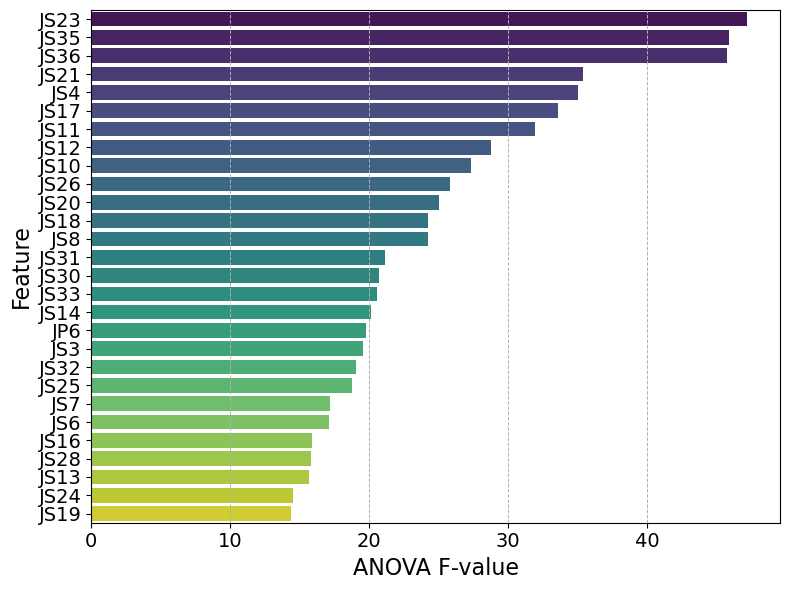

In [13]:
from sklearn.feature_selection import SelectKBest, f_classif
import seaborn as sns

# 특징선택 - ANOVA F-value 
selector = SelectKBest(score_func=f_classif, k=30)  

selector.fit(X_train, y_train)

X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# 스코어와 피쳐 정렬
sorted_indices = selector.scores_.argsort()[::-1]
sorted_scores = selector.scores_[sorted_indices]
sorted_features = X_train.columns[sorted_indices]

# 피쳐별 점수 확인
for feature, score in zip(sorted_features, sorted_scores):
    print(f"{feature}: {score}")

# df 생성
anova_df = pd.DataFrame({'Feature': sorted_features, 'F-value': sorted_scores})


# 시각화 - 바 차트
plt.figure(figsize=(8,6))
sns.barplot(data=anova_df[:28], x='F-value', y='Feature', palette='viridis')
# plt.title('ANOVA F-values for each feature', fontsize=16)
plt.xlabel('ANOVA F-value', fontsize=16)
plt.ylabel('Feature', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, axis='x', linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.show()

### Model Selection

In [15]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB


In [17]:
! pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ------ --------------------------------- 12.1/72.0 MB 63.1 MB/s eta 0:00:01
   ------------------ --------------------- 33.8/72.0 MB 82.6 MB/s eta 0:00:01
   ----------------------------- ---------- 53.7/72.0 MB 87.8 MB/s eta 0:00:01
   ---------------------------------------  71.8/72.0 MB 86.4 MB/s eta 0:00:01
   ---------------------------------------- 72.0/72.0 MB 79.2 MB/s eta 0:00:00


In [19]:
! pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)


In [20]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [21]:
# 하이퍼파라미터 정의
param_distributions = {
    'GaussianNB': {},  
    'DecisionTreeClassifier': {
        'max_depth': [None, 10, 20, 30, 40, 50],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'RandomForestClassifier': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'AdaBoostClassifier': {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.1, 1.0]
    },
    'LGBMClassifier': {
        'num_leaves': [31, 62, 127],
        'learning_rate': [0.01, 0.1, 0.5],
        'n_estimators': [100, 200, 300]
    },
    'XGBClassifier': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.5],
        'max_depth': [3, 6, 9]
    },
    'LinearRegression': {},  
    'LogisticRegression': {
        'C': np.logspace(-4, 4, 20),
        'solver': ['liblinear', 'lbfgs']
    },
    'SVC': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf']
    },
    'KNeighborsClassifier': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
}

# 모델링
models = {
    'GaussianNB': GaussianNB(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'RandomForestClassifier': RandomForestClassifier(),
    'AdaBoostClassifier': AdaBoostClassifier(),
    'LGBMClassifier': LGBMClassifier(random_state=42),
    'XGBClassifier': XGBClassifier(random_state=42),
    'LinearRegression': LinearRegression(),
    'LogisticRegression': LogisticRegression(),
    'SVC': SVC(),
    'KNeighborsClassifier': KNeighborsClassifier()
}

best_params = {}

for model_name, model in models.items():
    print(f"Running RandomizedSearchCV for {model_name}")
    clf = RandomizedSearchCV(model, param_distributions[model_name], n_iter=10, cv=5, verbose=2, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    best_params[model_name] = clf.best_params_
    print(f"Best parameters for {model_name}: {clf.best_params_}")

Running RandomizedSearchCV for GaussianNB
Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters for GaussianNB: {}
Running RandomizedSearchCV for DecisionTreeClassifier
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for DecisionTreeClassifier: {'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': None}
Running RandomizedSearchCV for RandomForestClassifier
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for RandomForestClassifier: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}
Running RandomizedSearchCV for AdaBoostClassifier
Fitting 5 folds for each of 9 candidates, totalling 45 fits


c:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Best parameters for AdaBoostClassifier: {'n_estimators': 50, 'learning_rate': 0.1}
Running RandomizedSearchCV for LGBMClassifier
Fitting 5 folds for each of 10 candidates, totalling 50 fits


...

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 157, number of negative: 90
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000276 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 334
[LightGBM] [Info] Number of data points in the train set: 247, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.635628 -> initscore=0.556436
[LightGBM] [Info] Start training from score 0.556436
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

c:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters for LogisticRegression: {'solver': 'lbfgs', 'C': 0.615848211066026}
Running RandomizedSearchCV for SVC
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters for SVC: {'kernel': 'linear', 'C': 0.1}
Running RandomizedSearchCV for KNeighborsClassifier
Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters for KNeighborsClassifier: {'weights': 'distance', 'n_neighbors': 7, 'metric': 'manhattan'}


### Model Training and Evaluation

Classification Report for GaussianNB:
              precision    recall  f1-score   support

           0     0.6087    0.6087    0.6087        23
           1     0.7692    0.7692    0.7692        39

    accuracy                         0.7097        62
   macro avg     0.6890    0.6890    0.6890        62
weighted avg     0.7097    0.7097    0.7097        62



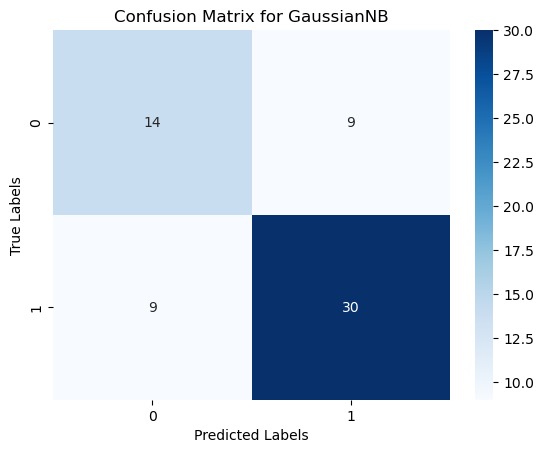

Classification Report for DecisionTreeClassifier:
              precision    recall  f1-score   support

           0     0.6818    0.6522    0.6667        23
           1     0.8000    0.8205    0.8101        39

    accuracy                         0.7581        62
   macro avg     0.7409    0.7363    0.7384        62
weighted avg     0.7562    0.7581    0.7569        62



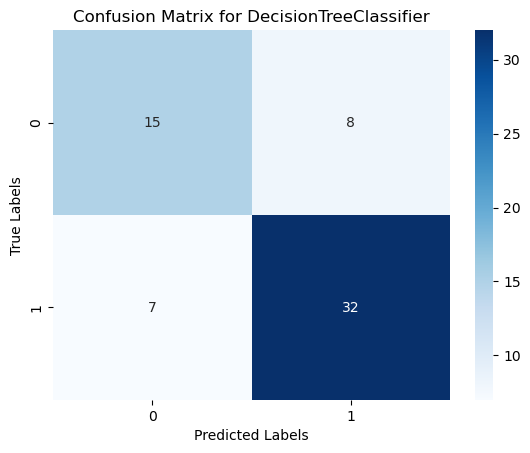

Classification Report for RandomForestClassifier:
              precision    recall  f1-score   support

           0     0.7895    0.6522    0.7143        23
           1     0.8140    0.8974    0.8537        39

    accuracy                         0.8065        62
   macro avg     0.8017    0.7748    0.7840        62
weighted avg     0.8049    0.8065    0.8020        62



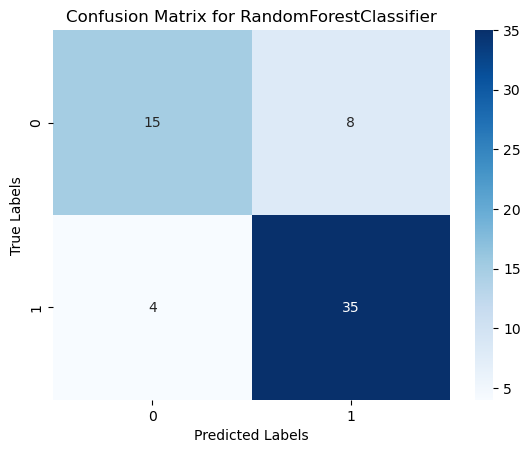

Classification Report for AdaBoostClassifier:
              precision    recall  f1-score   support

           0     0.8750    0.6087    0.7179        23
           1     0.8043    0.9487    0.8706        39

    accuracy                         0.8226        62
   macro avg     0.8397    0.7787    0.7943        62
weighted avg     0.8306    0.8226    0.8140        62



c:\Users\user\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


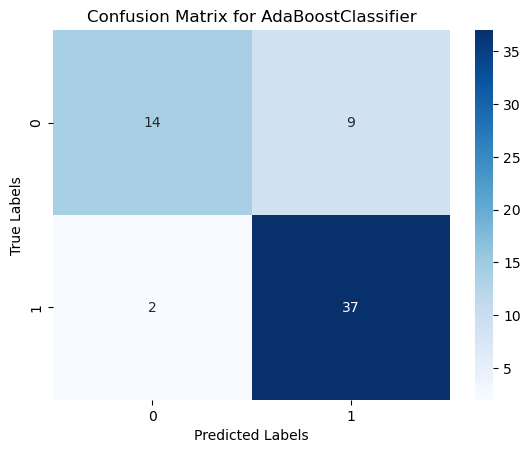

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 157, number of negative: 90
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000199 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 334
[LightGBM] [Info] Number of data points in the train set: 247, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.635628 -> initscore=0.556436
[LightGBM] [Info] Start training from score 0.556436
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

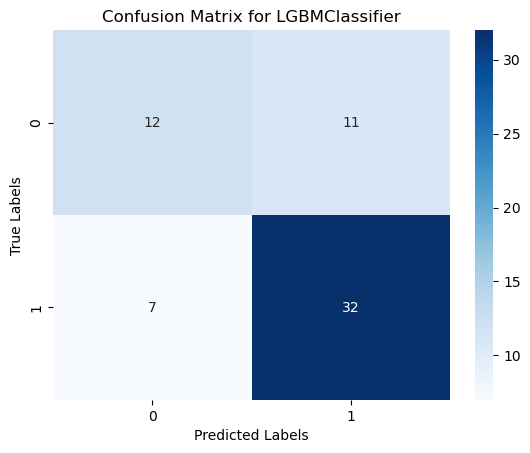

Classification Report for XGBClassifier:
              precision    recall  f1-score   support

           0     0.7143    0.6522    0.6818        23
           1     0.8049    0.8462    0.8250        39

    accuracy                         0.7742        62
   macro avg     0.7596    0.7492    0.7534        62
weighted avg     0.7713    0.7742    0.7719        62



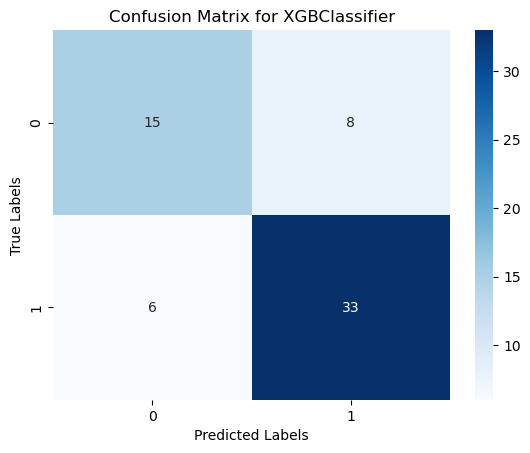

Classification Report for LogisticRegression:
              precision    recall  f1-score   support

           0     0.8182    0.7826    0.8000        23
           1     0.8750    0.8974    0.8861        39

    accuracy                         0.8548        62
   macro avg     0.8466    0.8400    0.8430        62
weighted avg     0.8539    0.8548    0.8541        62



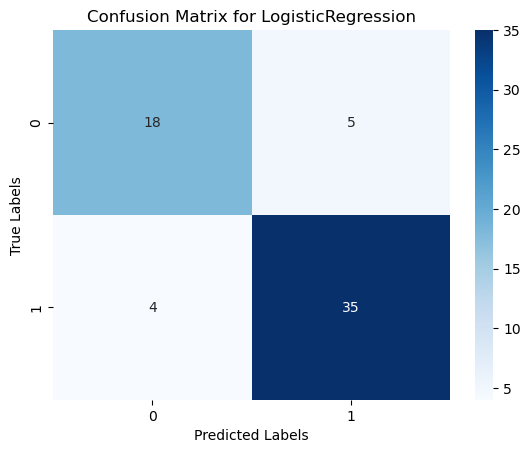

Classification Report for SVC:
              precision    recall  f1-score   support

           0     0.9000    0.7826    0.8372        23
           1     0.8810    0.9487    0.9136        39

    accuracy                         0.8871        62
   macro avg     0.8905    0.8657    0.8754        62
weighted avg     0.8880    0.8871    0.8852        62



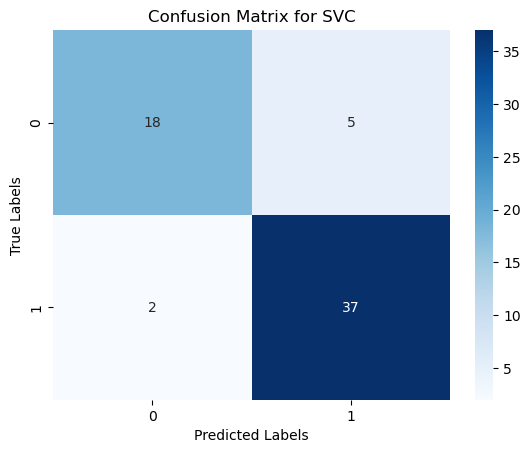

Classification Report for KNeighborsClassifier:
              precision    recall  f1-score   support

           0     0.8750    0.6087    0.7179        23
           1     0.8043    0.9487    0.8706        39

    accuracy                         0.8226        62
   macro avg     0.8397    0.7787    0.7943        62
weighted avg     0.8306    0.8226    0.8140        62



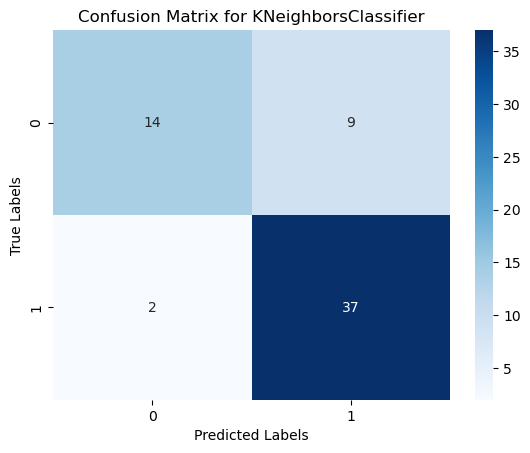

In [23]:
from sklearn.metrics import classification_report, confusion_matrix

for model_name, model in models.items():
    # 선형회귀 건너뛰기 (혼동행렬 및 분류모델이기에)
    if model_name == 'LinearRegression':
        continue

    # 최적의 매개변수 
    optimized_model = model.set_params(**best_params[model_name])

    optimized_model.fit(X_train, y_train)

    # 테스트 모델 예측
    y_pred = optimized_model.predict(X_test)

    # 분류 성능 보고서 시각화
    print(f"Classification Report for {model_name}:")
    print(classification_report(y_test, y_pred, digits = 4))

    # 혼동행렬 시각화
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

## RFECV

### Feature Selection